In [1]:
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [2]:
ROOT     = Path("/scratch/network/cr7998/cv_emergence_project")
CUB      = ROOT / "data" / "CUB_200_2011"
ATTR_TXT = ROOT / "data" / "attributes.txt"

# Bug 8 fix: GAMMAS defined once here; MCBM_FEATS derived from it.
# Previously _ALL_CANDIDATE_GAMMAS was a separate list that could diverge from GAMMAS.
GAMMAS     = [0.0, 0.05, 0.1, 0.2, 0.3, 0.5, 1.0]
MCBM_FEATS = {g: ROOT / "features" / f"resnet50_mcbm_gamma{g}" for g in GAMMAS}

assert CUB.exists(),      f"Missing CUB folder: {CUB}"
assert ATTR_TXT.exists(), f"Missing attributes.txt: {ATTR_TXT}"

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device: {device}")

device: cpu


In [3]:
LAYERS = [
    "conv1",
    "layer1.0", "layer1.1", "layer1.2",
    "layer2.0", "layer2.1", "layer2.2", "layer2.3",
    "layer3.0", "layer3.1", "layer3.2", "layer3.3", "layer3.4", "layer3.5",
    "layer4.0", "layer4.1", "layer4.2",
    "avgpool",
]
EMERGE_METRIC = "balanced"   # "balanced" | "plain"
EMERGE_FRAC   = 0.90

print(f"EMERGE_METRIC : {EMERGE_METRIC}")
print(f"EMERGE_FRAC   : {EMERGE_FRAC}")
print(f"LAYERS defined: {len(LAYERS)} layers from {LAYERS[0]} to {LAYERS[-1]}")

EMERGE_METRIC : balanced
EMERGE_FRAC   : 0.9
LAYERS defined: 18 layers from conv1 to avgpool


In [4]:
def load_species_maps(cub_root: Path):
    classes = pd.read_csv(
        cub_root / "classes.txt",
        sep=r"\s+", header=None,
        names=["species_id", "class_name"],
        engine="python"
    )
    def pretty(name: str) -> str:
        return name.split(".", 1)[-1].replace("_", " ")
    return dict(zip(
        classes["species_id"].astype(int),
        classes["class_name"].map(pretty),
    ))

species_id_to_name = load_species_maps(CUB)

def spname(sid: int) -> str:
    return species_id_to_name.get(int(sid), f"species_{sid}")

In [5]:
def load_meta(cub_root: Path) -> pd.DataFrame:
    img_species = pd.read_csv(
        cub_root / "image_class_labels.txt",
        sep=r"\s+", header=None,
        names=["image_id", "species_id"],
        engine="python"
    )
    split_df = pd.read_csv(
        cub_root / "train_test_split.txt",
        sep=r"\s+", header=None,
        names=["image_id", "is_train"],
        engine="python"
    )
    meta = img_species.merge(split_df, on="image_id")
    meta["species_name"] = meta["species_id"].map(spname)
    return meta

meta = load_meta(CUB)
print(f"meta: {len(meta)} images, {meta['species_id'].nunique()} species")

meta: 11788 images, 200 species


In [6]:
def load_image_attr_labels_robust(cub_root: Path) -> pd.DataFrame:
    path = cub_root / "attributes" / "image_attribute_labels.txt"
    rows = []
    bad  = 0
    with open(path, "r") as f:
        for line in f:
            toks = line.strip().split()
            if len(toks) < 4:
                bad += 1
                continue
            try:
                rows.append((int(toks[0]), int(toks[1]), int(toks[2]), int(toks[3])))
            except Exception:
                bad += 1
    df = pd.DataFrame(rows, columns=["image_id", "attr_id", "is_present", "certainty"])
    print(f"Parsed rows: {len(df)}  bad lines skipped: {bad}")
    return df

img_attr_long = load_image_attr_labels_robust(CUB)
img_attr_long.head()

Parsed rows: 3677856  bad lines skipped: 0


,image_id,attr_id,is_present,certainty
0,1,1,0,3
1,1,2,0,3
2,1,3,0,3
3,1,4,0,3
4,1,5,1,3


In [7]:
def load_attr_maps(attr_txt: Path):
    rows = []
    with open(attr_txt, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            aid_str, name = line.split(" ", 1)
            rows.append((int(aid_str), name))
    df = pd.DataFrame(rows, columns=["attr_id", "attr_name"])
    return df, dict(zip(df["attr_name"], df["attr_id"])), dict(zip(df["attr_id"], df["attr_name"]))

attr_df, attr_name_to_id, attr_id_to_name = load_attr_maps(ATTR_TXT)
print(f"attr_df: {len(attr_df)} attributes")
attr_df.head()

attr_df: 312 attributes


,attr_id,attr_name
0,1,has_bill_shape::curved_(up_or_down)
1,2,has_bill_shape::dagger
2,3,has_bill_shape::hooked
3,4,has_bill_shape::needle
4,5,has_bill_shape::hooked_seabird


In [8]:
def safe_torch_load(path: Path):
    try:
        return torch.load(path, map_location="cpu", weights_only=True)
    except TypeError:
        return torch.load(path, map_location="cpu")

def load_features(feat_dir: Path, layer: str, split: str) -> torch.Tensor:
    """Loads {layer}_{split}.pt from feat_dir. layer must be in LAYERS."""
    p = feat_dir / f"{layer}_{split}.pt"
    assert p.exists(), f"Missing: {p}"
    X = safe_torch_load(p)
    if not isinstance(X, torch.Tensor):
        X = torch.tensor(X)
    return X.float()

In [9]:
def to_1d_int_array(x) -> np.ndarray:
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu().numpy()
    return np.array(x).reshape(-1).astype(int)

def infer_kind(arr: np.ndarray) -> str:
    if arr.max() <= 200 and arr.min() >= 0:
        return "species_id_like"
    if arr.max() > 200:
        return "image_id_like"
    return "unknown"

def load_split_order(feat_dir: Path, split: str):
    p = feat_dir / f"labels_{split}.pt"
    assert p.exists(), f"Missing: {p}"
    t = torch.load(p, map_location="cpu", weights_only=True)
    assert isinstance(t, dict), f"Expected dict in {p}, got {type(t)}"
    assert "image_ids" in t,   f"{p} missing 'image_ids'; has {list(t.keys())}"
    ids  = to_1d_int_array(t["image_ids"])
    kind = infer_kind(ids)
    return kind, ids

In [10]:
_ref_feat = MCBM_FEATS[0.0]
mcbm_kind_tr, mcbm_ids_tr = load_split_order(_ref_feat, "train")
mcbm_kind_te, mcbm_ids_te = load_split_order(_ref_feat, "test")

print(f"MCBM split order: {mcbm_kind_tr}  id range: ({mcbm_ids_tr.min()}, {mcbm_ids_tr.max()})")
assert mcbm_kind_tr == "image_id_like", "Expected image_id_like for alignment to work"
assert mcbm_kind_te == "image_id_like", "Expected image_id_like for alignment to work"

MCBM split order: image_id_like  id range: (2, 11787)


In [11]:
def align_features_and_labels(
    X_split: torch.Tensor,
    image_ids_in_feature_order: np.ndarray,
    labeled_df_split: pd.DataFrame,
):
    """
    Aligns feature tensor rows (in DataLoader order) to attribute labels by image_id.
    Returns (X_aligned, df_aligned) with matching row order.
    labeled_df_split must have at most one row per image_id (guaranteed by
    build_attr_labeled_df's deduplication step).
    """
    labeled = labeled_df_split.set_index("image_id")[["y", "species_id", "species_name"]]
    keep_idx, rows = [], []
    for i, img_id in enumerate(image_ids_in_feature_order):
        img_id = int(img_id)
        if img_id in labeled.index:
            keep_idx.append(i)
            y, sid, sname = labeled.loc[img_id]
            rows.append((img_id, int(sid), str(sname), int(y)))
    X_aligned  = X_split[keep_idx]
    df_aligned = pd.DataFrame(rows, columns=["image_id", "species_id", "species_name", "y"])
    return X_aligned, df_aligned

In [12]:
def build_attr_labeled_df(
    meta: pd.DataFrame,
    img_attr_long: pd.DataFrame,
    attr_id: int,
    min_certainty: int = 1,
) -> pd.DataFrame:
    sub = img_attr_long[img_attr_long["attr_id"] == int(attr_id)].copy()
    sub = sub[sub["certainty"] >= int(min_certainty)].copy()
    # CUB has multiple annotators per (image, attribute); collapse to one row per image_id.
    # Using max is_present: attribute is present if any annotator marked it present.
    sub = (sub.groupby("image_id", as_index=False)
              .agg(is_present=("is_present", "max"), certainty=("certainty", "max")))
    out = meta.merge(sub[["image_id", "is_present", "certainty"]], on="image_id", how="inner")
    out = out.rename(columns={"is_present": "y"})
    out["y"] = out["y"].astype(int)
    return out[["image_id", "species_id", "species_name", "is_train", "y", "certainty"]]

# sanity check
_aid = attr_name_to_id["has_primary_color::yellow"]
_lab = build_attr_labeled_df(meta, img_attr_long, _aid, min_certainty=1)
print(f"Sanity: has_primary_color::yellow  rows={len(_lab)}  pos_rate={_lab.y.mean():.3f}")

Sanity: has_primary_color::yellow  rows=11788  pos_rate=0.151


In [13]:
class LinearProbe(nn.Module):
    def __init__(self, d: int):
        super().__init__()
        self.lin = nn.Linear(d, 1)
    def forward(self, x):
        return self.lin(x).squeeze(-1)

def train_probe(Xtr: torch.Tensor, ytr: np.ndarray,
                seed=0, lr=1e-2, wd=1e-4, epochs=25, batch=512):
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    Xtr   = Xtr.to(device)
    ytr_t = torch.tensor(ytr, dtype=torch.float32, device=device)
    probe = LinearProbe(Xtr.shape[1]).to(device)
    opt   = torch.optim.AdamW(probe.parameters(), lr=lr, weight_decay=wd)
    pos   = float(ytr_t.mean().item())
    pos_weight = (torch.tensor([(1 - pos) / pos], device=device)
                  if 0 < pos < 1 else torch.tensor([1.0], device=device))
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    n = Xtr.shape[0]
    for _ in range(epochs):
        perm = torch.randperm(n, device=device)
        for i in range(0, n, batch):
            idx    = perm[i:i+batch]
            logits = probe(Xtr[idx])
            loss   = loss_fn(logits, ytr_t[idx])
            opt.zero_grad(); loss.backward(); opt.step()
    return probe

@torch.no_grad()
def predict_probs(probe: nn.Module, X: torch.Tensor, batch=4096) -> np.ndarray:
    probe.eval()
    probs = []
    for i in range(0, X.shape[0], batch):
        logits = probe(X[i:i+batch].to(device))
        probs.append(torch.sigmoid(logits).detach().cpu())
    return torch.cat(probs, dim=0).numpy()

In [14]:
def bootstrap_ci(x, alpha=0.05):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if x.size == 0:
        return (np.nan, np.nan)
    return float(np.quantile(x, alpha / 2)), float(np.quantile(x, 1 - alpha / 2))

def bootstrap_p_value(values, null=0.0):
    v = np.asarray(values, dtype=float)
    v = v[~np.isnan(v)]
    if v.size == 0:
        return np.nan
    return float(2.0 * min(np.mean(v <= null), np.mean(v >= null)))

In [15]:
def eval_pair_vectorized(probs, y_arr, sid_arr, sid_A, sid_B,
                         mpos, n_seeds, seed=0, thr=0.5):
    """
    Bootstrap recall-gap statistics for one species pair — all seeds in one numpy call.
    Only positive examples are resampled (recall = TP/P); mneg is not needed here
    and is kept only in make_candidate_pairs where it guards pair feasibility.
    """
    rng   = np.random.default_rng(seed)
    A_pos = np.where((sid_arr == sid_A) & (y_arr == 1))[0]
    B_pos = np.where((sid_arr == sid_B) & (y_arr == 1))[0]
    iAp   = rng.integers(len(A_pos), size=(n_seeds, mpos))
    iBp   = rng.integers(len(B_pos), size=(n_seeds, mpos))
    pred_bin = (np.asarray(probs) >= thr).astype(np.int8)
    recA  = pred_bin[A_pos[iAp]].mean(axis=1)
    recB  = pred_bin[B_pos[iBp]].mean(axis=1)
    gaps  = np.abs(recA - recB)
    sgaps = recA - recB
    EPS   = 1e-12
    return {
        "sid_A": int(sid_A), "sid_B": int(sid_B),
        "species_A": spname(sid_A), "species_B": spname(sid_B),
        "npos": int(mpos),
        "gap_mean":  float(gaps.mean()),
        "gap_std":   float(gaps.std()),
        "gap_ci_lo": float(np.quantile(gaps, 0.025)),
        "gap_ci_hi": float(np.quantile(gaps, 0.975)),
        "gap_p":     float(2.0 * min(float(np.mean(sgaps <= 0)),
                                      float(np.mean(sgaps >= 0)))),
        "gap_snr":   float(gaps.mean() / (gaps.std() + EPS)),
        "gap_norm":  float(gaps.mean()),
        "n_runs":    n_seeds,
    }

def make_candidate_pairs(df_test: pd.DataFrame, min_each=10, max_pairs=200, seed=0):
    g   = df_test.groupby("species_id")["y"].agg(["count", "sum"]).rename(columns={"sum": "pos"})
    g["neg"] = g["count"] - g["pos"]
    ok  = g[(g["pos"] >= min_each) & (g["neg"] >= min_each)]
    sids = ok.index.to_list()
    rng  = np.random.default_rng(seed)
    pairs = []
    if len(sids) < 2:
        return pairs
    for _ in range(max_pairs * 10):
        a, b = rng.choice(sids, size=2, replace=False)
        mpos = int(min(ok.loc[a, "pos"], ok.loc[b, "pos"]))
        mneg = int(min(ok.loc[a, "neg"], ok.loc[b, "neg"]))
        if mpos >= min_each and mneg >= min_each:
            pairs.append((int(a), int(b), mpos, mneg))
        if len(pairs) >= max_pairs:
            break
    return pairs

def matched_pair_bootstrap_summary(df_te, probs, pairs, *, thr=0.5, B=300):
    """
    Returns pair_summary DataFrame (one row per pair).
    Bug 5 fix: previously returned (pd.DataFrame(), pair_summary) — the first value
    was always an empty DataFrame and every caller ignored it with _.
    """
    if not pairs:
        return pd.DataFrame()
    y_arr   = df_te["y"].to_numpy(dtype=int)
    sid_arr = df_te["species_id"].to_numpy()
    rows = [
        eval_pair_vectorized(probs, y_arr, sid_arr, a, b, mpos,
                             n_seeds=B, seed=i, thr=thr)
        for i, (a, b, mpos, mneg) in enumerate(pairs)
    ]
    pair_summary = pd.DataFrame(rows)
    pair_summary["gap_ci_width"] = pair_summary["gap_ci_hi"] - pair_summary["gap_ci_lo"]
    return pair_summary.sort_values("gap_mean", ascending=False).reset_index(drop=True)

In [16]:
def species_recall_prevalence_table(df_te, probs, thr=0.5):
    df = df_te[["species_id", "species_name", "y"]].copy()
    df["prob"] = np.asarray(probs, dtype=float)
    df["pred"] = (df["prob"] >= thr).astype(int)
    g = (df.groupby(["species_id", "species_name"], as_index=False)
           .agg(n=("y","size"), n_pos=("y","sum"), n_pred_pos=("pred","sum")))
    g["n_neg"]      = g["n"] - g["n_pos"]
    g["prevalence"] = g["n_pos"] / g["n"]
    tp = (df[df["y"]==1].groupby(["species_id","species_name"])["pred"]
            .sum().reset_index(name="tp"))
    out = g.merge(tp, on=["species_id","species_name"], how="left")
    out["tp"]        = out["tp"].fillna(0).astype(int)
    out["recall"]    = np.where(out["n_pos"]>0, out["tp"]/out["n_pos"], np.nan)
    out["precision"] = np.where(out["n_pred_pos"]>0, out["tp"]/out["n_pred_pos"], np.nan)
    return out.sort_values("n", ascending=False).reset_index(drop=True)

def add_species_bootstrap_ci(df_te, probs, thr=0.5, B=300, min_pos_for_ci=1):
    # Bug 3 fix: reset to 0-based index so grp.index positional indexing into
    # y_arr/p_arr is safe even if df_te originated from a non-contiguous slice.
    df_te = df_te.reset_index(drop=True)
    base  = species_recall_prevalence_table(df_te, probs, thr=thr)
    y_arr = df_te["y"].to_numpy(dtype=int)
    p_arr = np.asarray(probs, dtype=float)
    rng   = np.random.default_rng(0)
    ci_rows = []
    for (sid, sname), grp in df_te.groupby(["species_id","species_name"]):
        idx   = grp.index.to_numpy()
        y_s   = y_arr[idx]; p_s = p_arr[idx]; n = len(idx)
        n_pos = int(y_s.sum())
        if n_pos < min_pos_for_ci:
            ci_rows.append({"species_id":int(sid),"species_name":str(sname),
                            "recall_bs_mean":np.nan,"recall_ci_lo":np.nan,
                            "recall_ci_hi":np.nan,"recall_ci_width":np.nan,"B":B})
            continue
        boot_idx  = rng.integers(0, n, size=(B, n))
        y_boot    = y_s[boot_idx]; p_boot = p_s[boot_idx]
        pos_mask  = (y_boot==1); pred_mask = (p_boot>=thr)
        n_pos_bt  = pos_mask.sum(axis=1); tp_bt = (pos_mask & pred_mask).sum(axis=1)
        with np.errstate(invalid="ignore"):
            recalls = np.where(n_pos_bt>0, tp_bt/n_pos_bt, np.nan)
        lo, hi = bootstrap_ci(recalls)
        ci_rows.append({"species_id":int(sid),"species_name":str(sname),
                        "recall_bs_mean":float(np.nanmean(recalls)),
                        "recall_ci_lo":lo,"recall_ci_hi":hi,
                        "recall_ci_width":(hi-lo) if np.isfinite(lo) and np.isfinite(hi) else np.nan,
                        "B":B})
    return base.merge(pd.DataFrame(ci_rows), on=["species_id","species_name"], how="left")

print("Section 3 defined.")

Section 3 defined.


In [17]:
def balanced_accuracy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = y_true.astype(int).reshape(-1)
    y_pred = y_pred.astype(int).reshape(-1)
    tp = int(((y_true==1)&(y_pred==1)).sum()); tn = int(((y_true==0)&(y_pred==0)).sum())
    fp = int(((y_true==0)&(y_pred==1)).sum()); fn = int(((y_true==1)&(y_pred==0)).sum())
    tpr = tp/(tp+fn) if (tp+fn)>0 else 0.0
    tnr = tn/(tn+fp) if (tn+fp)>0 else 0.0
    return 0.5*(tpr+tnr)

def frac_of_final_idx(vals: np.ndarray, frac: float = None) -> int:
    """Earliest index i such that vals[i] >= frac * vals[-1]. Uses EMERGE_FRAC if frac=None."""
    if frac is None:
        frac = EMERGE_FRAC
    v = pd.Series(np.asarray(vals, dtype=float)).ffill().bfill().to_numpy()
    target = frac * float(v[-1])
    for i, x in enumerate(v):
        if float(x) >= target:
            return int(i)
    return int(len(v)-1)

def sharp_rise_idx(vals: np.ndarray) -> int:
    """Index of the largest single-step increase."""
    v = pd.Series(np.asarray(vals, dtype=float)).ffill().bfill().to_numpy()
    return int(np.argmax(np.diff(v))) + 1

def train_linear_probe_multiclass(Xtr, ytr, Xte, yte, *,
                                  epochs=6, lr=3e-3, wd=1e-4, seed=0, metric="plain"):
    """
    Bug 2 fix: added metric parameter.
    metric="plain"    → plain accuracy (fraction correct)
    metric="balanced" → macro-average per-class recall (mean recall across all classes)
    EMERGE_METRIC is passed in from the call site so the species emergence curve
    uses the configured metric rather than always using plain accuracy.
    """
    torch.manual_seed(seed)
    Xtr_t = torch.as_tensor(Xtr, dtype=torch.float32, device=device)
    ytr_t = torch.as_tensor(ytr, dtype=torch.long,    device=device)
    Xte_t = torch.as_tensor(Xte, dtype=torch.float32, device=device)
    d = Xtr_t.shape[1]; C = int(ytr_t.max().item()) + 1
    model = nn.Linear(d, C).to(device)
    opt   = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    loss_fn = nn.CrossEntropyLoss()
    for _ in range(epochs):
        model.train(); opt.zero_grad()
        loss_fn(model(Xtr_t), ytr_t).backward(); opt.step()
    model.eval()
    with torch.no_grad():
        pred = model(Xte_t).argmax(dim=1).cpu().numpy()
    if metric == "balanced":
        classes = np.unique(yte)
        per_class = [float((pred[yte == c] == c).mean()) for c in classes if (yte == c).sum() > 0]
        return float(np.mean(per_class)) if per_class else 0.0
    return float((pred == yte).mean())

def train_linear_probe_binary_weighted(Xtr, ytr, Xte, yte, *,
                                       epochs=8, lr=3e-3, wd=1e-4, seed=0, threshold=0.5):
    torch.manual_seed(seed)
    ytr_np = np.asarray(ytr, dtype=np.int32).reshape(-1)
    yte_np = np.asarray(yte, dtype=np.int32).reshape(-1)
    Xtr_t  = torch.as_tensor(Xtr, dtype=torch.float32).to(device)
    Xte_t  = torch.as_tensor(Xte, dtype=torch.float32).to(device)
    ytr_t  = torch.as_tensor(ytr_np, dtype=torch.float32).view(-1,1).to(device)
    d = int(Xtr_t.shape[1])
    model = nn.Linear(d, 1).to(device)
    opt   = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    pos   = float(ytr_np.sum()); neg = float(len(ytr_np) - ytr_np.sum())
    if pos <= 0:
        probs = np.zeros_like(yte_np, dtype=float)
        return 0.5, float((np.zeros_like(yte_np)==yte_np).mean()), 0.0, probs
    pos_weight = torch.tensor([neg/max(pos,1.0)], dtype=torch.float32).to(device)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    for _ in range(epochs):
        model.train(); opt.zero_grad()
        loss_fn(model(Xtr_t), ytr_t).backward(); opt.step()
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(Xte_t)).view(-1).cpu().numpy()
    pred = (probs >= threshold).astype(int)
    ba   = balanced_accuracy(yte_np, pred)
    return float(ba), float((pred==yte_np).mean()), float(pred.mean()), probs

In [18]:
# Use gamma=0.0 (standard CBM, least regularised) as reference backbone.
_ref_dir = MCBM_FEATS[0.0]

# Compute alignment indices once — same for all layers since DataLoader order is fixed.
_ref_ids_tr = np.asarray(mcbm_ids_tr, dtype=int)
_ref_ids_te = np.asarray(mcbm_ids_te, dtype=int)

meta_tr_set = set(meta[meta["is_train"]==1]["image_id"].astype(int))
meta_te_set = set(meta[meta["is_train"]==0]["image_id"].astype(int))

keep_tr_idx    = np.array([i for i, iid in enumerate(_ref_ids_tr) if iid in meta_tr_set], dtype=int)
keep_te_idx    = np.array([i for i, iid in enumerate(_ref_ids_te) if iid in meta_te_set], dtype=int)
aligned_tr_ids = _ref_ids_tr[keep_tr_idx]
aligned_te_ids = _ref_ids_te[keep_te_idx]

_meta_idx = meta.set_index("image_id")
ysp_tr    = _meta_idx.loc[aligned_tr_ids, "species_id"].to_numpy(dtype=np.int64) - 1
ysp_te    = _meta_idx.loc[aligned_te_ids, "species_id"].to_numpy(dtype=np.int64) - 1

print(f"Aligned: train={len(aligned_tr_ids)}, test={len(aligned_te_ids)}")

# Bug 7 fix: load one layer at a time — never hold all 18 tensors in memory at once.
species_curve = []
for L in LAYERS:
    Xtr_raw = load_features(_ref_dir, L, "train")
    Xte_raw = load_features(_ref_dir, L, "test")
    Xtr_L   = Xtr_raw[keep_tr_idx]; del Xtr_raw
    Xte_L   = Xte_raw[keep_te_idx]; del Xte_raw
    acc = train_linear_probe_multiclass(
        Xtr_L, ysp_tr, Xte_L, ysp_te,
        epochs=15, seed=0, metric=EMERGE_METRIC,
    )
    del Xtr_L, Xte_L
    species_curve.append(acc)
    print(f"  {L:12s}  {acc:.4f}")

species_curve = np.asarray(species_curve, dtype=float)
print(f"\nDone. Loaded and discarded {len(LAYERS)} layer pairs.")

Aligned: train=5994, test=5794
  conv1         0.0091
  layer1.0      0.0270
  layer1.1      0.0308
  layer1.2      0.0317
  layer2.0      0.0400
  layer2.1      0.0465
  layer2.2      0.0522
  layer2.3      0.0554
  layer3.0      0.0793
  layer3.1      0.0918
  layer3.2      0.0978
  layer3.3      0.1037
  layer3.4      0.1177
  layer3.5      0.1310
  layer4.0      0.3850
  layer4.1      0.4551
  layer4.2      0.7082
  avgpool       0.7082

Done. Loaded and discarded 18 layer pairs.



Species emergence layer: index=14  layer=layer4.0
Metric used: balanced
Per-layer species accuracy:
  conv1         0.0091
  layer1.0      0.0270
  layer1.1      0.0308
  layer1.2      0.0317
  layer2.0      0.0400
  layer2.1      0.0465
  layer2.2      0.0522
  layer2.3      0.0554
  layer3.0      0.0793
  layer3.1      0.0918
  layer3.2      0.0978
  layer3.3      0.1037
  layer3.4      0.1177
  layer3.5      0.1310
  layer4.0      0.3850  <-- PROBE_LAYER
  layer4.1      0.4551
  layer4.2      0.7082
  avgpool       0.7082


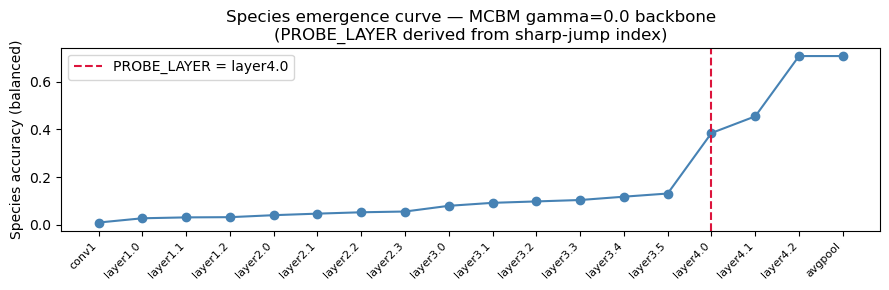

PROBE_LAYER = 'layer4.0'  (used for all matched-pair analyses below)


In [19]:
species_emerge_idx = sharp_rise_idx(species_curve)
PROBE_LAYER = LAYERS[species_emerge_idx]

print(f"\nSpecies emergence layer: index={species_emerge_idx}  layer={PROBE_LAYER}")
print(f"Metric used: {EMERGE_METRIC}")
print("Per-layer species accuracy:")
for L, a in zip(LAYERS, species_curve):
    marker = "  <-- PROBE_LAYER" if L == PROBE_LAYER else ""
    print(f"  {L:12s}  {a:.4f}{marker}")

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(range(len(LAYERS)), species_curve, marker="o", color="steelblue")
ax.axvline(species_emerge_idx, color="crimson", linestyle="--",
           label=f"PROBE_LAYER = {PROBE_LAYER}")
ax.set_xticks(range(len(LAYERS)))
ax.set_xticklabels(LAYERS, rotation=45, ha="right", fontsize=8)
ax.set_ylabel(f"Species accuracy ({EMERGE_METRIC})")
ax.set_title("Species emergence curve — MCBM gamma=0.0 backbone\n"
             "(PROBE_LAYER derived from sharp-jump index)")
ax.legend()
plt.tight_layout()
plt.savefig("mcbm_species_emergence_curve.png", dpi=150)
plt.show()
print(f"PROBE_LAYER = {PROBE_LAYER!r}  (used for all matched-pair analyses below)")

In [20]:
def run_one_attribute(
    attr_name: str,
    feat_dir: Path,
    split_order_kind_train: str,
    split_order_train: np.ndarray,
    split_order_kind_test: str,
    split_order_test: np.ndarray,
    layer: str,
    *,
    Xtr_all: torch.Tensor = None,
    Xte_all: torch.Tensor = None,
    min_certainty: int = 1,
    thr: float = 0.5,
    epochs: int = 25,
    min_each: int = 10,
    n_pairs: int = 200,
    B_gap: int = 100,
    B_species: int = 100,
):
    assert split_order_kind_train == "image_id_like" and split_order_kind_test == "image_id_like", (
        "labels_{split}.pt must contain image_ids for alignment to work."
    )
    # Bug 6 fix: only load from disk if not pre-supplied by the caller.
    if Xtr_all is None:
        Xtr_all = load_features(feat_dir, layer, "train")
    if Xte_all is None:
        Xte_all = load_features(feat_dir, layer, "test")

    aid       = attr_name_to_id[attr_name]
    lab       = build_attr_labeled_df(meta, img_attr_long, aid, min_certainty=min_certainty)
    lab_train = lab[lab["is_train"]==1].copy()
    lab_test  = lab[lab["is_train"]==0].copy()

    Xtr, df_tr = align_features_and_labels(Xtr_all, split_order_train, lab_train)
    Xte, df_te = align_features_and_labels(Xte_all, split_order_test,  lab_test)

    ytr = df_tr["y"].astype(int).to_numpy()
    yte = df_te["y"].astype(int).to_numpy()

    probe = train_probe(Xtr, ytr, seed=0, epochs=epochs)
    probs = predict_probs(probe, Xte)

    species_table = add_species_bootstrap_ci(df_te, probs, thr=thr, B=B_species)
    test_acc      = float(((probs>=thr).astype(int)==yte).mean()) if len(yte) else np.nan

    if n_pairs is None or int(n_pairs) <= 0:
        pairs = []; pair_summary = pd.DataFrame()
    else:
        pairs = make_candidate_pairs(df_te, min_each=min_each, max_pairs=n_pairs, seed=0)
        # Bug 5 fix: matched_pair_bootstrap_summary now returns only pair_summary.
        pair_summary = matched_pair_bootstrap_summary(df_te, probs, pairs, thr=thr, B=B_gap)

    mean_gap = float(pair_summary["gap_mean"].mean())        if len(pair_summary) else np.nan
    p90_gap  = float(pair_summary["gap_mean"].quantile(0.9)) if len(pair_summary) else np.nan

    info = {
        "attr": attr_name, "layer": layer,
        "n_train": int(len(df_tr)), "n_test": int(len(df_te)),
        "train_pos_rate": float(ytr.mean()) if len(ytr) else np.nan,
        "test_pos_rate":  float(yte.mean()) if len(yte) else np.nan,
        "test_acc": float(test_acc), "thr": float(thr), "epochs": int(epochs),
        "n_pairs": int(len(pairs)), "B_gap": int(B_gap), "B_species": int(B_species),
        "mean_gap": mean_gap, "p90_gap": p90_gap,
    }
    # Second return value is a placeholder empty DataFrame kept for API compatibility
    # with callers that expect a 5-tuple (info, _, pair_summary, df_te, species_table).
    return info, pd.DataFrame(), pair_summary, df_te, species_table

In [21]:
def screen_attributes(candidate_attrs, feat_dir, kind_tr, ids_tr, kind_te, ids_te, layer, *,
                      min_certainty=1, thr=0.5, min_pos_per_species=10, min_species_with_pos=15,
                      min_overall_prev=0.05, max_overall_prev=0.95, epochs=8,
                      max_attrs=None, verbose_every=50, B_species=200):
    rows, errors = [], []
    stats = {"tried":0,"success":0,"filtered_too_few_species_pos":0,
             "filtered_prev_out_of_range":0,"filtered_no_recall_vals":0,"errored":0}
    cand = list(candidate_attrs)[:max_attrs] if max_attrs else list(candidate_attrs)

    for i, attr in enumerate(cand):
        stats["tried"] += 1
        try:
            info, _, _, _, st = run_one_attribute(
                attr, feat_dir, kind_tr, ids_tr, kind_te, ids_te,
                layer=layer, min_certainty=min_certainty, thr=thr,
                epochs=epochs, min_each=10, n_pairs=0, B_species=B_species,
            )
            overall_prev   = float(st["n_pos"].sum()/st["n"].sum()) if st["n"].sum()>0 else np.nan
            st_pos         = st[st["n_pos"]>=min_pos_per_species]
            n_species_pos  = int(len(st_pos))
            if n_species_pos < min_species_with_pos:
                stats["filtered_too_few_species_pos"] += 1; continue
            if not (min_overall_prev <= overall_prev <= max_overall_prev):
                stats["filtered_prev_out_of_range"] += 1; continue
            recall_vals = st_pos["recall"].dropna().to_numpy()
            if recall_vals.size == 0:
                stats["filtered_no_recall_vals"] += 1; continue
            stats["success"] += 1
            rows.append({
                "attr": attr, "overall_prev": overall_prev,
                "n_species_pos": n_species_pos,
                "recall_std":    float(np.std(recall_vals)),
                "recall_range":  float(np.max(recall_vals)-np.min(recall_vals)),
                "recall_p90_p10": float(np.quantile(recall_vals,0.9)-np.quantile(recall_vals,0.1)),
                "test_acc": float(info["test_acc"]), "n_test": int(info["n_test"]),
            })
            if verbose_every and (i+1)%verbose_every==0:
                print(f"[{i+1}/{len(cand)}] {attr}  prev={overall_prev:.3f}  n_sp={n_species_pos}")
        except Exception as e:
            stats["errored"] += 1
            if len(errors) < 5: errors.append((attr, repr(e)))

    print("\n--- Screening summary ---")
    for k, v in stats.items(): print(f"  {k}: {v}")
    if errors:
        print("\nErrors (first few):"); [print(f"  {a} -> {m}") for a,m in errors]

    if not rows:
        return pd.DataFrame()
    return (pd.DataFrame(rows)
              .sort_values(["recall_p90_p10","recall_range","recall_std"], ascending=False)
              .reset_index(drop=True))

In [22]:
# Bug 9 fix: shuffle with fixed seed so max_attrs cap is random, not biased by attr_id order.
# Without this, attrs with high attr_id (last 112 of 312) are never screened.
_rng_attrs = np.random.default_rng(42)
CANDIDATE_ATTRS = _rng_attrs.permutation(attr_df["attr_name"].tolist()).tolist()

screen_df = screen_attributes(
    CANDIDATE_ATTRS, MCBM_FEATS[0.0],
    mcbm_kind_tr, mcbm_ids_tr, mcbm_kind_te, mcbm_ids_te,
    layer=PROBE_LAYER,
    min_certainty=1, thr=0.5,
    min_pos_per_species=10, min_species_with_pos=15,
    min_overall_prev=0.05, max_overall_prev=0.95,
    epochs=8, max_attrs=200, verbose_every=25,
)

if screen_df.empty:
    print("Loosening filters...")
    _rng_attrs2 = np.random.default_rng(42)
    CANDIDATE_ATTRS2 = _rng_attrs2.permutation(attr_df["attr_name"].tolist()).tolist()
    screen_df = screen_attributes(
        CANDIDATE_ATTRS2, MCBM_FEATS[0.0],
        mcbm_kind_tr, mcbm_ids_tr, mcbm_kind_te, mcbm_ids_te,
        layer=PROBE_LAYER,
        min_certainty=1, thr=0.5,
        min_pos_per_species=5, min_species_with_pos=8,
        min_overall_prev=0.02, max_overall_prev=0.98,
        epochs=6, max_attrs=200, verbose_every=25,
    )

TOP_K = 12
ATTR_LIST = screen_df["attr"].head(TOP_K).tolist()
attr_to_spread = screen_df.set_index("attr")["recall_p90_p10"].to_dict()

print(f"\nATTR_LIST ({len(ATTR_LIST)} attributes):")
for a in ATTR_LIST: print(f"  {a}")
screen_df.head(20)

[25/200] has_breast_pattern::striped  prev=0.118  n_sp=26

--- Screening summary ---
  tried: 200
  success: 75
  filtered_too_few_species_pos: 125
  filtered_prev_out_of_range: 0
  filtered_no_recall_vals: 0
  errored: 0

ATTR_LIST (12 attributes):
  has_bill_length::about_the_same_as_head
  has_wing_color::black
  has_breast_pattern::solid
  has_under_tail_color::black
  has_upper_tail_color::white
  has_upperparts_color::grey
  has_wing_pattern::striped
  has_head_pattern::capped
  has_bill_shape::cone
  has_primary_color::black
  has_under_tail_color::white
  has_throat_color::white


,attr,overall_prev,n_species_pos,recall_std,recall_range,recall_p90_p10,test_acc,n_test
0,has_bill_length::about_the_same_as_head,0.365723,91,0.308007,1.000000,0.800000,0.701415,5794
1,has_wing_color::black,0.424750,115,0.289191,0.928571,0.766207,0.668105,5794
2,has_breast_pattern::solid,0.544356,154,0.278089,1.000000,0.757790,0.652917,5794
3,has_under_tail_color::black,0.312047,76,0.276194,0.961538,0.726496,0.713324,5794
4,has_upper_tail_color::white,0.125992,27,0.292769,0.900000,0.716538,0.845702,5794
5,has_upperparts_color::grey,0.295305,75,0.268912,0.909091,0.680693,0.684501,5794
6,has_wing_pattern::striped,0.224888,52,0.246942,1.000000,0.679327,0.686227,5794
7,has_head_pattern::capped,0.115292,18,0.260318,0.769231,0.662692,0.863997,5794
8,has_bill_shape::cone,0.253366,56,0.272342,1.000000,0.658333,0.749914,5794
9,has_primary_color::black,0.355540,85,0.261485,1.000000,0.654545,0.718674,5794


In [23]:
# Bug 8 fix: GAMMAS already defined in Cell 0-2. Just verify dirs exist.
_missing = [g for g in GAMMAS if not MCBM_FEATS.get(g, Path("__missing__")).exists()]
if _missing:
    print(f"WARNING: Missing feature dirs for gammas: {_missing}")
    print("These gammas will be skipped. Run run_mcbm_extract_adroit.sh for missing values.")
    GAMMAS = [g for g in GAMMAS if g not in _missing]
print(f"Running sweep over gammas: {GAMMAS}")

def run_many(attr_list, model_name, feat_dir, kind_tr, ids_tr, kind_te, ids_te, *,
             layer, min_certainty=1, thr=0.5, epochs=25, min_each=10,
             n_pairs=200, B_gap=100, B_species=100):
    """
    Runs run_one_attribute over attr_list for one model / one gamma.
    Bug 6 fix: features loaded once per (feat_dir, layer) here, then passed into
    run_one_attribute so the same .pt file is not reloaded once per attribute.
    Returns (info_df, pairs_df, species_df).
    """
    Xtr_all = load_features(feat_dir, layer, "train")
    Xte_all = load_features(feat_dir, layer, "test")
    print(f"  Loaded features: {layer}_train {tuple(Xtr_all.shape)}, {layer}_test {tuple(Xte_all.shape)}")

    all_info, all_pair_summ, all_species = [], [], []
    for attr in attr_list:
        info, _, pair_summ, _, species_table = run_one_attribute(
            attr, feat_dir, kind_tr, ids_tr, kind_te, ids_te,
            layer=layer,
            Xtr_all=Xtr_all, Xte_all=Xte_all,
            min_certainty=min_certainty, thr=thr,
            epochs=epochs, min_each=min_each, n_pairs=n_pairs,
            B_gap=B_gap, B_species=B_species,
        )
        info = dict(info); info["model"] = model_name
        all_info.append(info)
        if pair_summ is not None and len(pair_summ):
            ps = pair_summ.copy(); ps["attr"] = attr; ps["model"] = model_name
            all_pair_summ.append(ps)
        st = species_table.copy(); st["attr"] = attr; st["model"] = model_name
        all_species.append(st)
        print(f"{model_name}  {attr}  test_acc={info['test_acc']:.4f}  mean_gap={info['mean_gap']:.4f}")
    info_df    = pd.DataFrame(all_info)
    pairs_df   = pd.concat(all_pair_summ, ignore_index=True) if all_pair_summ else pd.DataFrame()
    species_df = pd.concat(all_species,   ignore_index=True) if all_species   else pd.DataFrame()
    return info_df, pairs_df, species_df

These gammas will be skipped. Run run_mcbm_extract_adroit.sh for missing values.
Running sweep over gammas: [0.0, 0.1, 0.5, 1.0]


In [24]:
mcbm_results = {}   # g -> (info_df, pairs_df, species_df)

for g in GAMMAS:
    print(f"\n{'='*60}")
    print(f"  MCBM gamma={g}  (PROBE_LAYER={PROBE_LAYER})")
    print(f"{'='*60}")
    info, pairs, species = run_many(
        ATTR_LIST, f"mcbm_gamma{g}", MCBM_FEATS[g],
        mcbm_kind_tr, mcbm_ids_tr,
        mcbm_kind_te, mcbm_ids_te,
        layer=PROBE_LAYER,
        thr=0.5, n_pairs=200, B_gap=100, B_species=100,
    )
    mcbm_results[g] = (info, pairs, species)
    species.to_csv(f"mcbm_species_gamma{g}.csv", index=False)
    print(f"Saved mcbm_species_gamma{g}.csv ({len(species)} rows)")

print("\nDone. Results in mcbm_results[gamma].")


  MCBM gamma=0.0  (PROBE_LAYER=layer4.0)
  Loaded features: layer4.0_train (5994, 2048), layer4.0_test (5794, 2048)
mcbm_gamma0.0  has_bill_length::about_the_same_as_head  test_acc=0.6702  mean_gap=0.3070
mcbm_gamma0.0  has_wing_color::black  test_acc=0.6876  mean_gap=0.3363
mcbm_gamma0.0  has_breast_pattern::solid  test_acc=0.6754  mean_gap=0.2934
mcbm_gamma0.0  has_under_tail_color::black  test_acc=0.5618  mean_gap=0.1737
mcbm_gamma0.0  has_upper_tail_color::white  test_acc=0.8473  mean_gap=0.3940
mcbm_gamma0.0  has_upperparts_color::grey  test_acc=0.7211  mean_gap=0.3088
mcbm_gamma0.0  has_wing_pattern::striped  test_acc=0.6862  mean_gap=0.2550
mcbm_gamma0.0  has_head_pattern::capped  test_acc=0.6448  mean_gap=0.2676
mcbm_gamma0.0  has_bill_shape::cone  test_acc=0.6923  mean_gap=0.3088
mcbm_gamma0.0  has_primary_color::black  test_acc=0.7233  mean_gap=0.3073
mcbm_gamma0.0  has_under_tail_color::white  test_acc=0.7584  mean_gap=0.2747
mcbm_gamma0.0  has_throat_color::white  test_acc

In [25]:
def summarize_by_attr(pairs_df: pd.DataFrame) -> pd.DataFrame:
    if pairs_df.empty:
        return pairs_df
    tmp = pairs_df.copy()
    tmp["_ci_above0"] = tmp["gap_ci_lo"] > 0
    tmp["_p_small"]   = tmp["gap_p"] <= 0.05
    out = (
        tmp.groupby(["model", "attr"], as_index=False)
           .agg(
               gap_mean       = ("gap_mean",    "mean"),
               gap_median     = ("gap_mean",    "median"),
               gap_max        = ("gap_mean",    "max"),
               n_pairs        = ("gap_mean",    "size"),
               frac_p_small   = ("_p_small",    "mean"),
               frac_ci_above0 = ("_ci_above0",  "mean"),
               gap_snr_mean   = ("gap_snr",     "mean"),
           )
           .sort_values(["model", "gap_mean"], ascending=[True, False])
    )
    return out

def add_gap_interpretability_cols(pair_df: pd.DataFrame) -> pd.DataFrame:
    out = pair_df.copy()
    out["gap_snr"]      = out["gap_mean"] / out["gap_std"].replace(0, np.nan)
    out["prev_matched"] = (out["npos"] / out["npos"]).astype(float)  # always 1.0; placeholder
    out["gap_norm"]     = out["gap_mean"] / 1.0
    return out

In [26]:
def top_pairs(pairs_df: pd.DataFrame, model: str, attr: str, k: int = 10) -> pd.DataFrame:
    sub = pairs_df[
        (pairs_df["model"] == model) & (pairs_df["attr"] == attr)
    ].copy()
    if sub.empty:
        return sub
    cols = [
        "species_A", "species_B",
        "gap_mean", "gap_ci_lo", "gap_ci_hi", "gap_p",
        "gap_std", "gap_snr", "gap_norm",
        "npos", "n_runs",
    ]
    cols = [c for c in cols if c in sub.columns]
    return sub.sort_values("gap_mean", ascending=False).head(k)[cols]

In [27]:
all_summaries = {}

for g in GAMMAS:
    _, pairs, _ = mcbm_results[g]
    if pairs.empty:
        print(f"gamma={g}: no pairs data")
        continue
    pairs_enr = add_gap_interpretability_cols(pairs)
    s = summarize_by_attr(pairs_enr)
    all_summaries[g] = s
    print(f"\n{'='*55}")
    print(f"  Per-attribute summary  gamma={g}  (PROBE_LAYER={PROBE_LAYER})")
    print(f"{'='*55}")
    display(s)


  Per-attribute summary  gamma=0.0  (PROBE_LAYER=layer4.0)


,model,attr,gap_mean,gap_median,gap_max,n_pairs,frac_p_small,frac_ci_above0,gap_snr_mean
8,mcbm_gamma0.0,has_upper_tail_color::white,0.393973,0.370742,0.848000,200,0.48,0.545,2.784344
10,mcbm_gamma0.0,has_wing_color::black,0.336315,0.273149,0.819231,200,0.32,0.425,2.306279
9,mcbm_gamma0.0,has_upperparts_color::grey,0.308829,0.254478,0.809091,200,0.26,0.360,2.059664
1,mcbm_gamma0.0,has_bill_shape::cone,0.308804,0.263923,0.722000,200,0.30,0.360,2.047882
4,mcbm_gamma0.0,has_primary_color::black,0.307337,0.256667,0.850000,200,0.27,0.355,2.080419
0,mcbm_gamma0.0,has_bill_length::about_the_same_as_head,0.306992,0.249373,0.926667,200,0.30,0.360,2.331966
2,mcbm_gamma0.0,has_breast_pattern::solid,0.293431,0.214641,0.934667,200,0.24,0.310,2.125073
5,mcbm_gamma0.0,has_throat_color::white,0.277839,0.235500,0.817000,200,0.21,0.310,1.888975
7,mcbm_gamma0.0,has_under_tail_color::white,0.274719,0.206571,0.757273,200,0.24,0.325,1.943308
3,mcbm_gamma0.0,has_head_pattern::capped,0.267555,0.230839,0.736667,200,0.31,0.380,2.076155



  Per-attribute summary  gamma=0.1  (PROBE_LAYER=layer4.0)


,model,attr,gap_mean,gap_median,gap_max,n_pairs,frac_p_small,frac_ci_above0,gap_snr_mean
8,mcbm_gamma0.1,has_upper_tail_color::white,0.379663,0.361250,0.763000,200,0.465,0.515,2.549277
10,mcbm_gamma0.1,has_wing_color::black,0.336855,0.292136,0.843333,200,0.385,0.470,2.288569
5,mcbm_gamma0.1,has_throat_color::white,0.330301,0.281667,0.932857,200,0.340,0.445,2.335925
0,mcbm_gamma0.1,has_bill_length::about_the_same_as_head,0.320582,0.262231,0.929000,200,0.335,0.420,2.401859
4,mcbm_gamma0.1,has_primary_color::black,0.318065,0.264500,0.941000,200,0.325,0.385,2.215909
9,mcbm_gamma0.1,has_upperparts_color::grey,0.317271,0.266611,0.923333,200,0.280,0.350,2.180989
2,mcbm_gamma0.1,has_breast_pattern::solid,0.315824,0.257727,0.903000,200,0.300,0.400,2.134411
1,mcbm_gamma0.1,has_bill_shape::cone,0.254479,0.209286,0.747273,200,0.150,0.215,1.741362
7,mcbm_gamma0.1,has_under_tail_color::white,0.249608,0.189702,0.617000,200,0.230,0.310,1.874623
11,mcbm_gamma0.1,has_wing_pattern::striped,0.243839,0.177143,0.918000,200,0.190,0.225,1.963007



  Per-attribute summary  gamma=0.5  (PROBE_LAYER=layer4.0)


,model,attr,gap_mean,gap_median,gap_max,n_pairs,frac_p_small,frac_ci_above0,gap_snr_mean
0,mcbm_gamma0.5,has_bill_length::about_the_same_as_head,0.343236,0.295000,1.000000,200,0.400,0.500,2.481522
10,mcbm_gamma0.5,has_wing_color::black,0.331152,0.285000,0.872727,200,0.345,0.415,2.269710
8,mcbm_gamma0.5,has_upper_tail_color::white,0.327828,0.221333,0.823000,200,0.385,0.425,2.374319
9,mcbm_gamma0.5,has_upperparts_color::grey,0.318313,0.276364,0.797273,200,0.260,0.355,2.103190
5,mcbm_gamma0.5,has_throat_color::white,0.307376,0.271090,0.805714,200,0.325,0.445,2.073966
1,mcbm_gamma0.5,has_bill_shape::cone,0.306593,0.254231,0.716923,200,0.330,0.400,2.060665
2,mcbm_gamma0.5,has_breast_pattern::solid,0.298913,0.237273,1.000000,200,0.275,0.345,2.135297
4,mcbm_gamma0.5,has_primary_color::black,0.289524,0.225308,0.941000,200,0.205,0.290,2.068186
11,mcbm_gamma0.5,has_wing_pattern::striped,0.288578,0.205487,0.914167,200,0.265,0.300,2.404035
7,mcbm_gamma0.5,has_under_tail_color::white,0.239976,0.191000,0.619000,200,0.270,0.320,1.869927



  Per-attribute summary  gamma=1.0  (PROBE_LAYER=layer4.0)


,model,attr,gap_mean,gap_median,gap_max,n_pairs,frac_p_small,frac_ci_above0,gap_snr_mean
10,mcbm_gamma1.0,has_wing_color::black,0.356892,0.303036,0.938462,200,0.375,0.480,2.506203
8,mcbm_gamma1.0,has_upper_tail_color::white,0.336268,0.220000,0.872000,200,0.380,0.415,2.574995
2,mcbm_gamma1.0,has_breast_pattern::solid,0.318595,0.226643,0.906000,200,0.280,0.370,2.248605
0,mcbm_gamma1.0,has_bill_length::about_the_same_as_head,0.300952,0.244500,0.926667,200,0.325,0.405,2.251291
5,mcbm_gamma1.0,has_throat_color::white,0.300537,0.243429,0.823000,200,0.220,0.325,2.059375
9,mcbm_gamma1.0,has_upperparts_color::grey,0.299178,0.251538,0.851818,200,0.225,0.335,1.985823
4,mcbm_gamma1.0,has_primary_color::black,0.295628,0.231250,0.830000,200,0.270,0.340,2.028216
1,mcbm_gamma1.0,has_bill_shape::cone,0.270670,0.230000,0.662727,200,0.235,0.280,1.799632
3,mcbm_gamma1.0,has_head_pattern::capped,0.231170,0.192083,0.648571,200,0.190,0.260,1.753920
11,mcbm_gamma1.0,has_wing_pattern::striped,0.230284,0.163500,0.841667,200,0.200,0.245,1.848581


In [28]:
import os

_cbm_csv = "cbm_species.csv"
if os.path.exists(_cbm_csv):
    cbm_ref = pd.read_csv(_cbm_csv)
    _, _, species_g0 = mcbm_results[0.0]

    _g0_mean  = species_g0.groupby("attr")["recall"].mean().rename("recall_mcbm_g0")
    _cbm_mean = cbm_ref.groupby("attr")["recall"].mean().rename("recall_cbm")
    _comp = pd.concat([_g0_mean, _cbm_mean], axis=1).dropna()
    _comp["delta"] = _comp["recall_mcbm_g0"] - _comp["recall_cbm"]

    print("\nSanity check: gamma=0.0 vs. cbm_species.csv")
    print("(delta should be small — both are standard CBM at layer PROBE_LAYER)")
    display(_comp)
else:
    print(f"\nSanity check skipped: {_cbm_csv} not found.")
    print("Run recall.ipynb first and save cbm_species.csv to enable this check.")


Sanity check: gamma=0.0 vs. cbm_species.csv
(delta should be small — both are standard CBM at layer PROBE_LAYER)


,recall_mcbm_g0,recall_cbm,delta
attr,,,
has_breast_pattern::solid,0.677989,0.551072,0.126917
has_under_tail_color::black,0.682915,0.513105,0.169811
has_under_tail_color::white,0.349963,0.538931,-0.188967
has_upper_tail_color::white,0.207231,0.356305,-0.149074
has_wing_color::black,0.482763,0.522042,-0.039280


In [29]:
for g in GAMMAS:
    _, pairs, _ = mcbm_results[g]
    if pairs.empty:
        print(f"gamma={g}: no pairs"); continue
    pairs_enr = add_gap_interpretability_cols(pairs)
    print(f"\n{'='*60}")
    print(f"  Top species pairs  gamma={g}  (PROBE_LAYER={PROBE_LAYER})")
    print(f"{'='*60}")
    for attr in ATTR_LIST:
        print(f"\n  Attribute: {attr}")
        display(top_pairs(pairs_enr, f"mcbm_gamma{g}", attr, k=5))


  Top species pairs  gamma=0.0  (PROBE_LAYER=layer4.0)

  Attribute: has_bill_length::about_the_same_as_head


,species_A,species_B,gap_mean,gap_ci_lo,gap_ci_hi,gap_p,gap_std,gap_snr,gap_norm,npos,n_runs
0,Western Grebe,Orchard Oriole,0.926667,0.800000,1.0,0.0,0.067659,13.696077,0.926667,15,100
1,Long tailed Jaeger,Orchard Oriole,0.924000,0.800000,1.0,0.0,0.066010,13.997858,0.924000,15,100
2,Baltimore Oriole,Western Grebe,0.922727,0.727273,1.0,0.0,0.076466,12.067097,0.922727,11,100
3,Horned Puffin,Orchard Oriole,0.850714,0.642857,1.0,0.0,0.099023,8.591052,0.850714,14,100
4,Louisiana Waterthrush,Orchard Oriole,0.843000,0.600000,1.0,0.0,0.115978,7.268592,0.843000,10,100



  Attribute: has_wing_color::black


,species_A,species_B,gap_mean,gap_ci_lo,gap_ci_hi,gap_p,gap_std,gap_snr,gap_norm,npos,n_runs
200,Pigeon Guillemot,Tennessee Warbler,0.819231,0.538462,1.000000,0.0,0.111671,7.336110,0.819231,13,100
201,Savannah Sparrow,Bay breasted Warbler,0.804545,0.545455,1.000000,0.0,0.122221,6.582701,0.804545,11,100
202,Henslow Sparrow,Lazuli Bunting,0.802143,0.605357,1.000000,0.0,0.098900,8.110682,0.802143,14,100
203,Cape Glossy Starling,Henslow Sparrow,0.786429,0.533929,0.966071,0.0,0.114060,6.894865,0.786429,14,100
204,Indigo Bunting,Horned Puffin,0.759000,0.500000,1.000000,0.0,0.139352,5.446636,0.759000,10,100



  Attribute: has_breast_pattern::solid


...

,species_A,species_B,gap_mean,gap_ci_lo,gap_ci_hi,gap_p,gap_std,gap_snr,gap_norm,npos,n_runs
1800,Le Conte Sparrow,Baltimore Oriole,0.830000,0.625000,1.0000,0.0,0.096047,8.641615,0.830000,16,100
1801,Nighthawk,Le Conte Sparrow,0.787273,0.454545,1.0000,0.0,0.131250,5.998289,0.787273,11,100
1802,White crowned Sparrow,Pacific Loon,0.784000,0.500000,1.0000,0.0,0.130935,5.987699,0.784000,10,100
1803,Cape Glossy Starling,Le Conte Sparrow,0.780000,0.428571,1.0000,0.0,0.134271,5.809168,0.780000,14,100
1804,Le Conte Sparrow,Hooded Oriole,0.768125,0.592187,0.9375,0.0,0.098542,7.794891,0.768125,16,100



  Attribute: has_under_tail_color::white


,species_A,species_B,gap_mean,gap_ci_lo,gap_ci_hi,gap_p,gap_std,gap_snr,gap_norm,npos,n_runs
2000,Pied Kingfisher,Chipping Sparrow,0.433333,0.166667,0.750000,0.00,0.169148,2.561856,0.433333,12,100
2001,Cactus Wren,Black and white Warbler,0.425000,0.100000,0.700000,0.02,0.152561,2.785762,0.425000,10,100
2002,Chipping Sparrow,Ring billed Gull,0.416667,0.166667,0.710417,0.00,0.147667,2.821663,0.416667,12,100
2003,Red bellied Woodpecker,Chipping Sparrow,0.415000,0.166667,0.666667,0.00,0.136920,3.030956,0.415000,12,100
2004,Chipping Sparrow,Red bellied Woodpecker,0.412500,0.166667,0.750000,0.00,0.149710,2.755320,0.412500,12,100



  Attribute: has_throat_color::white


,species_A,species_B,gap_mean,gap_ci_lo,gap_ci_hi,gap_p,gap_std,gap_snr,gap_norm,npos,n_runs
2200,Florida Jay,White crowned Sparrow,0.823000,0.600000,1.000000,0.0,0.121536,6.771656,0.823000,10,100
2201,Green tailed Towhee,Chestnut sided Warbler,0.800000,0.583333,1.000000,0.0,0.111181,7.195504,0.800000,12,100
2202,Chestnut sided Warbler,Tropical Kingbird,0.796842,0.551316,0.947368,0.0,0.106576,7.476748,0.796842,19,100
2203,White eyed Vireo,Clay colored Sparrow,0.750833,0.416667,1.000000,0.0,0.143127,5.245914,0.750833,12,100
2204,European Goldfinch,Black and white Warbler,0.743571,0.500000,0.928571,0.0,0.112529,6.607826,0.743571,14,100


In [30]:
_, _, species_g0 = mcbm_results[0.0]
print(f"\nMCBM gamma=0.0 species recall (sorted by true positives, PROBE_LAYER={PROBE_LAYER}):")
display(species_g0.sort_values("tp", ascending=False).head(30))


MCBM gamma=0.0 species recall (sorted by true positives, PROBE_LAYER=layer4.0):


,species_id,species_name,n,n_pos,n_pred_pos,n_neg,prevalence,tp,recall,precision,recall_bs_mean,recall_ci_lo,recall_ci_hi,recall_ci_width,B,attr,model
258,192,Downy Woodpecker,30,30,30,0,1.000000,30,1.000000,1.000000,1.000000,1.000000,1.0,0.000000,100,has_wing_color::black,mcbm_gamma0.0
448,177,Prothonotary Warbler,30,30,30,0,1.000000,30,1.000000,1.000000,1.000000,1.000000,1.0,0.000000,100,has_breast_pattern::solid,mcbm_gamma0.0
1917,29,American Crow,30,30,30,0,1.000000,30,1.000000,1.000000,1.000000,1.000000,1.0,0.000000,100,has_primary_color::black,mcbm_gamma0.0
517,29,American Crow,30,30,30,0,1.000000,30,1.000000,1.000000,1.000000,1.000000,1.0,0.000000,100,has_breast_pattern::solid,mcbm_gamma0.0
1933,10,Red winged Blackbird,30,29,30,1,0.966667,29,1.000000,0.966667,1.000000,1.000000,1.0,0.000000,100,has_primary_color::black,mcbm_gamma0.0
1838,107,Common Raven,30,29,30,1,0.966667,29,1.000000,0.966667,1.000000,1.000000,1.0,0.000000,100,has_primary_color::black,mcbm_gamma0.0
1919,30,Fish Crow,30,29,30,1,0.966667,29,1.000000,0.966667,1.000000,1.000000,1.0,0.000000,100,has_primary_color::black,mcbm_gamma0.0
1855,188,Pileated Woodpecker,30,29,29,1,0.966667,28,0.965517,0.965517,0.965754,0.890774,1.0,0.109226,100,has_primary_color::black,mcbm_gamma0.0
2270,146,Forsters Tern,30,29,29,1,0.966667,28,0.965517,0.965517,0.966026,0.892857,1.0,0.107143,100,has_throat_color::white,mcbm_gamma0.0
454,186,Cedar Waxwing,30,28,30,2,0.933333,28,1.000000,0.933333,1.000000,1.000000,1.0,0.000000,100,has_breast_pattern::solid,mcbm_gamma0.0


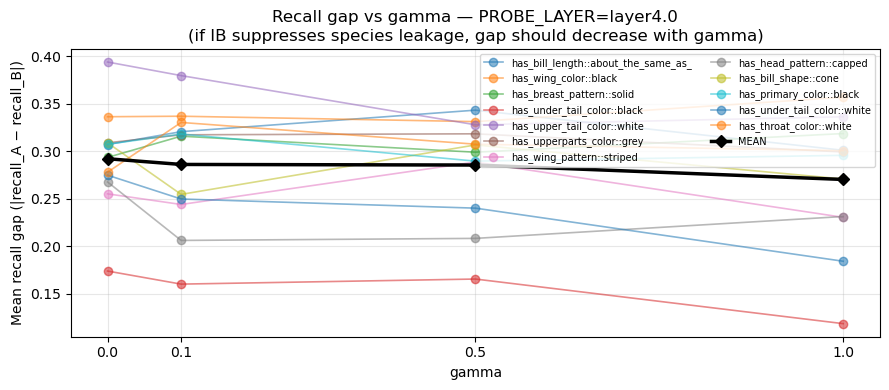

In [31]:
# ── Cell 8-1: Mean recall gap vs gamma (per attribute + overall mean) ────────
# This is the primary result: does increasing gamma reduce species-entanglement
# in concept representations?

fig, ax = plt.subplots(figsize=(9, 4))

gap_by_gamma = {}
for g in GAMMAS:
    _, pairs, _ = mcbm_results[g]
    if pairs.empty:
        gap_by_gamma[g] = {}
        continue
    for attr in ATTR_LIST:
        sub = pairs[pairs["attr"] == attr]
        if not sub.empty:
            gap_by_gamma.setdefault(g, {})[attr] = float(sub["gap_mean"].mean())

for attr in ATTR_LIST:
    ys = [gap_by_gamma.get(g, {}).get(attr, np.nan) for g in GAMMAS]
    ax.plot(GAMMAS, ys, marker="o", alpha=0.55, linewidth=1.2, label=attr[:35])

# Overall mean across attributes
overall = [np.nanmean([gap_by_gamma.get(g, {}).get(a, np.nan) for a in ATTR_LIST]) for g in GAMMAS]
ax.plot(GAMMAS, overall, marker="D", color="black", linewidth=2.5, label="MEAN", zorder=5)

ax.set_xlabel("gamma")
ax.set_ylabel("Mean recall gap (|recall_A − recall_B|)")
ax.set_title(f"Recall gap vs gamma — PROBE_LAYER={PROBE_LAYER}\n"
             f"(if IB suppresses species leakage, gap should decrease with gamma)")
ax.legend(fontsize=7, loc="upper right", ncol=2)
ax.grid(True, alpha=0.3)
ax.set_xticks(GAMMAS)
plt.tight_layout()
plt.savefig("mcbm_gap_vs_gamma.png", dpi=150)
plt.show()

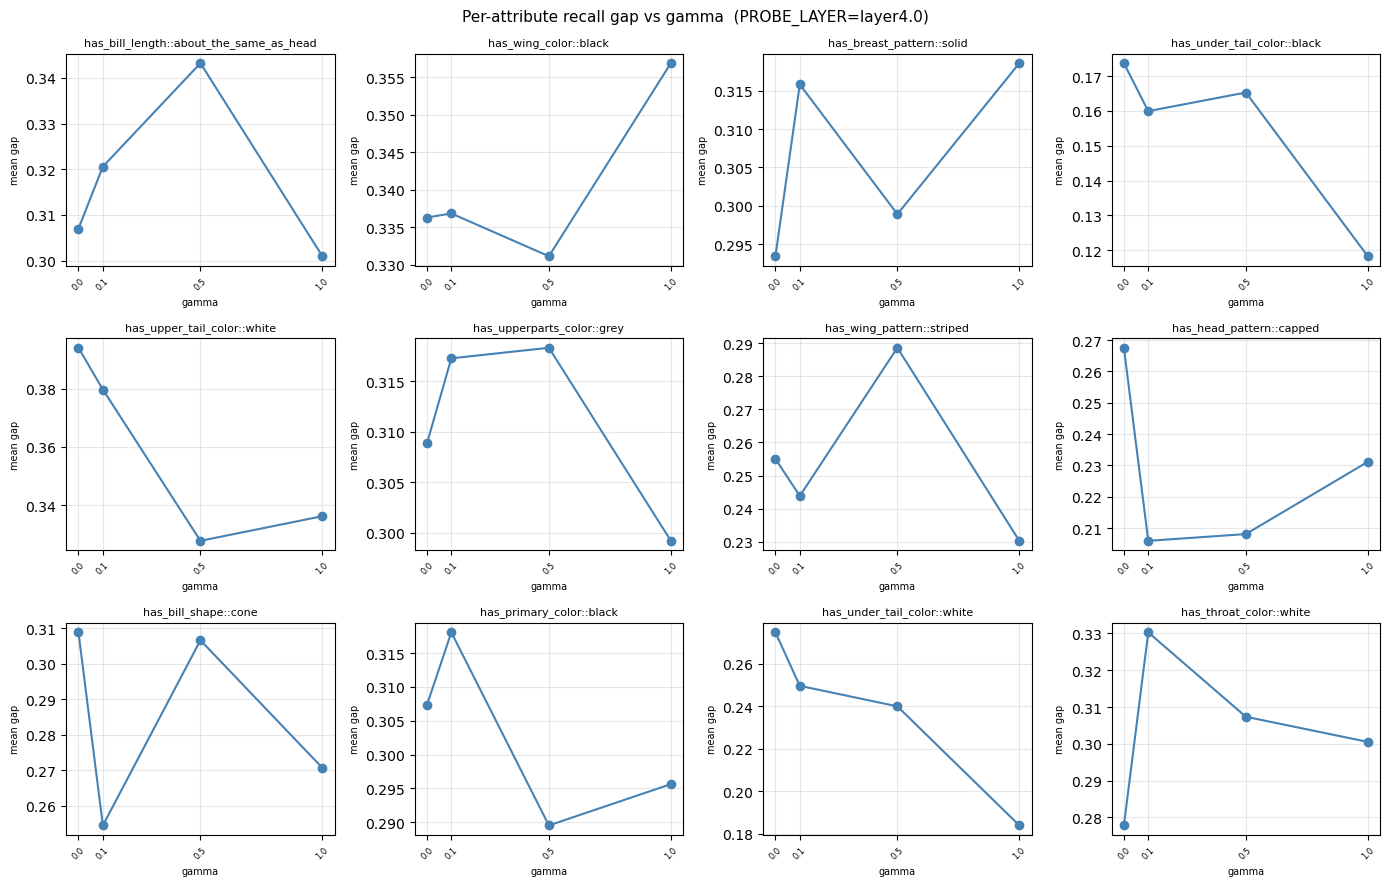

In [32]:
# ── Cell 8-2: Per-attribute gap vs gamma (small multiples) ──────────────────
ncols = 4
nrows = int(np.ceil(len(ATTR_LIST) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3 * nrows), sharey=False)
axes = np.array(axes).reshape(-1)

for idx, attr in enumerate(ATTR_LIST):
    ax = axes[idx]
    ys = [gap_by_gamma.get(g, {}).get(attr, np.nan) for g in GAMMAS]
    ax.plot(GAMMAS, ys, marker="o", color="steelblue")
    ax.set_title(attr[:40], fontsize=8)
    ax.set_xlabel("gamma", fontsize=7)
    ax.set_ylabel("mean gap", fontsize=7)
    ax.set_xticks(GAMMAS)
    ax.tick_params(axis="x", labelsize=6, rotation=45)
    ax.grid(True, alpha=0.3)

for ax in axes[len(ATTR_LIST):]:
    ax.set_visible(False)

fig.suptitle(f"Per-attribute recall gap vs gamma  (PROBE_LAYER={PROBE_LAYER})", fontsize=11)
plt.tight_layout()
plt.savefig("mcbm_gap_vs_gamma_per_attr.png", dpi=150)
plt.show()

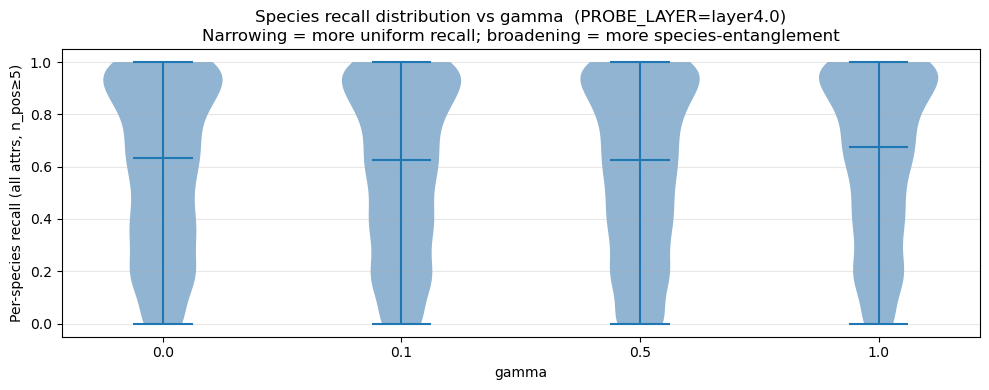

In [33]:
# ── Cell 8-3: Violin plot of per-species recall distribution by gamma ────────
# Shows whether gamma flattens or spreads per-species recall across species.

records = []
for g in GAMMAS:
    _, _, species = mcbm_results[g]
    if species.empty:
        continue
    for attr in ATTR_LIST:
        sub = species[(species["attr"] == attr) & (species["n_pos"] >= 5)]
        for r in sub["recall"].dropna():
            records.append({"gamma": str(g), "recall": float(r), "attr": attr})

df_violin = pd.DataFrame(records)

if not df_violin.empty:
    gamma_order = [str(g) for g in GAMMAS]
    fig, ax = plt.subplots(figsize=(10, 4))
    parts = ax.violinplot(
        [df_violin[df_violin["gamma"] == gstr]["recall"].to_numpy()
         for gstr in gamma_order if gstr in df_violin["gamma"].values],
        positions=range(len(gamma_order)),
        showmedians=True, showextrema=True,
    )
    for pc in parts["bodies"]:
        pc.set_facecolor("steelblue"); pc.set_alpha(0.6)
    ax.set_xticks(range(len(gamma_order)))
    ax.set_xticklabels(gamma_order)
    ax.set_xlabel("gamma")
    ax.set_ylabel("Per-species recall (all attrs, n_pos≥5)")
    ax.set_title(f"Species recall distribution vs gamma  (PROBE_LAYER={PROBE_LAYER})\n"
                 "Narrowing = more uniform recall; broadening = more species-entanglement")
    ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.savefig("mcbm_recall_violin_by_gamma.png", dpi=150)
    plt.show()

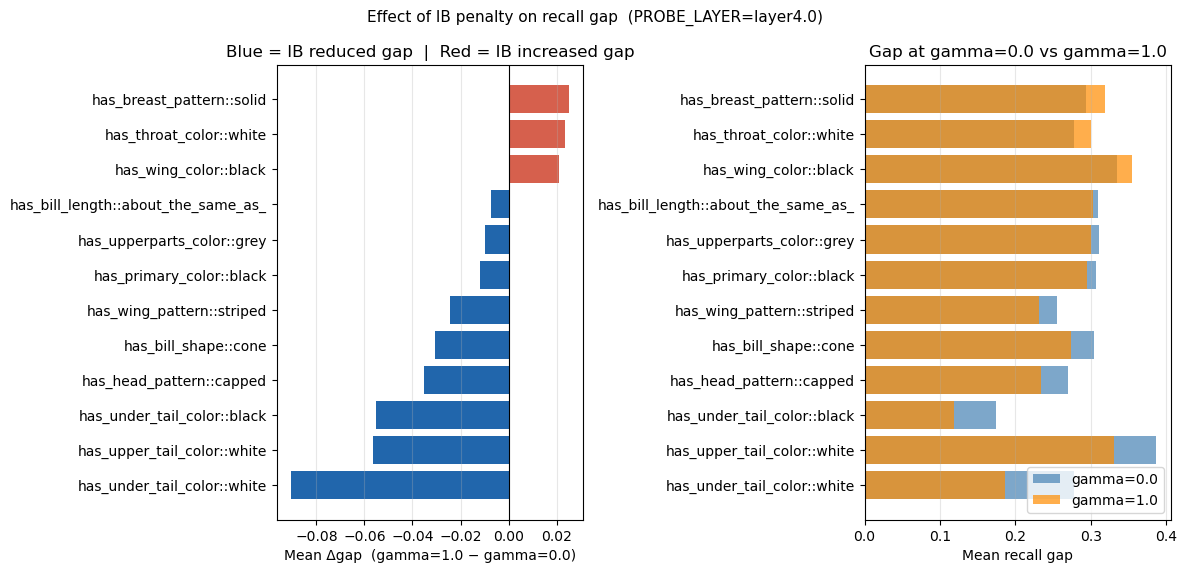

In [34]:
# ── Cell 8-4: Heatmap of gap change: gamma=max minus gamma=0 ─────────────────
# Positive = gap increased (more entangled); negative = gap decreased (IB working).

g_lo, g_hi = GAMMAS[0], GAMMAS[-1]
_, pairs_lo, _ = mcbm_results[g_lo]
_, pairs_hi, _ = mcbm_results[g_hi]

rows = []
for attr in ATTR_LIST:
    sub_lo = pairs_lo[pairs_lo["attr"] == attr]
    sub_hi = pairs_hi[pairs_hi["attr"] == attr]
    if sub_lo.empty or sub_hi.empty:
        continue
    # Align by species pair
    lo_map = sub_lo.set_index(["sid_A", "sid_B"])["gap_mean"].to_dict()
    hi_map = sub_hi.set_index(["sid_A", "sid_B"])["gap_mean"].to_dict()
    keys   = set(lo_map) & set(hi_map)
    deltas = [hi_map[k] - lo_map[k] for k in keys]
    rows.append({
        "attr":      attr[:35],
        "mean_gap_lo":  float(np.mean([lo_map[k] for k in keys])),
        "mean_gap_hi":  float(np.mean([hi_map[k] for k in keys])),
        "mean_delta":   float(np.mean(deltas)),
        "n_pairs":      len(deltas),
    })

df_delta = pd.DataFrame(rows).sort_values("mean_delta")

if not df_delta.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, max(3, len(df_delta) * 0.4 + 1)))

    colors = ["#2166ac" if v < 0 else "#d6604d" for v in df_delta["mean_delta"]]
    axes[0].barh(df_delta["attr"], df_delta["mean_delta"], color=colors)
    axes[0].axvline(0, color="black", linewidth=0.8)
    axes[0].set_xlabel(f"Mean Δgap  (gamma={g_hi} − gamma={g_lo})")
    axes[0].set_title("Blue = IB reduced gap  |  Red = IB increased gap")
    axes[0].grid(True, alpha=0.3, axis="x")

    axes[1].barh(df_delta["attr"], df_delta["mean_gap_lo"],
                 label=f"gamma={g_lo}", alpha=0.7, color="steelblue")
    axes[1].barh(df_delta["attr"], df_delta["mean_gap_hi"],
                 label=f"gamma={g_hi}", alpha=0.7, color="darkorange")
    axes[1].set_xlabel("Mean recall gap")
    axes[1].set_title(f"Gap at gamma={g_lo} vs gamma={g_hi}")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, axis="x")

    fig.suptitle(f"Effect of IB penalty on recall gap  (PROBE_LAYER={PROBE_LAYER})", fontsize=11)
    plt.tight_layout()
    plt.savefig("mcbm_gap_delta_heatmap.png", dpi=150)
    plt.show()

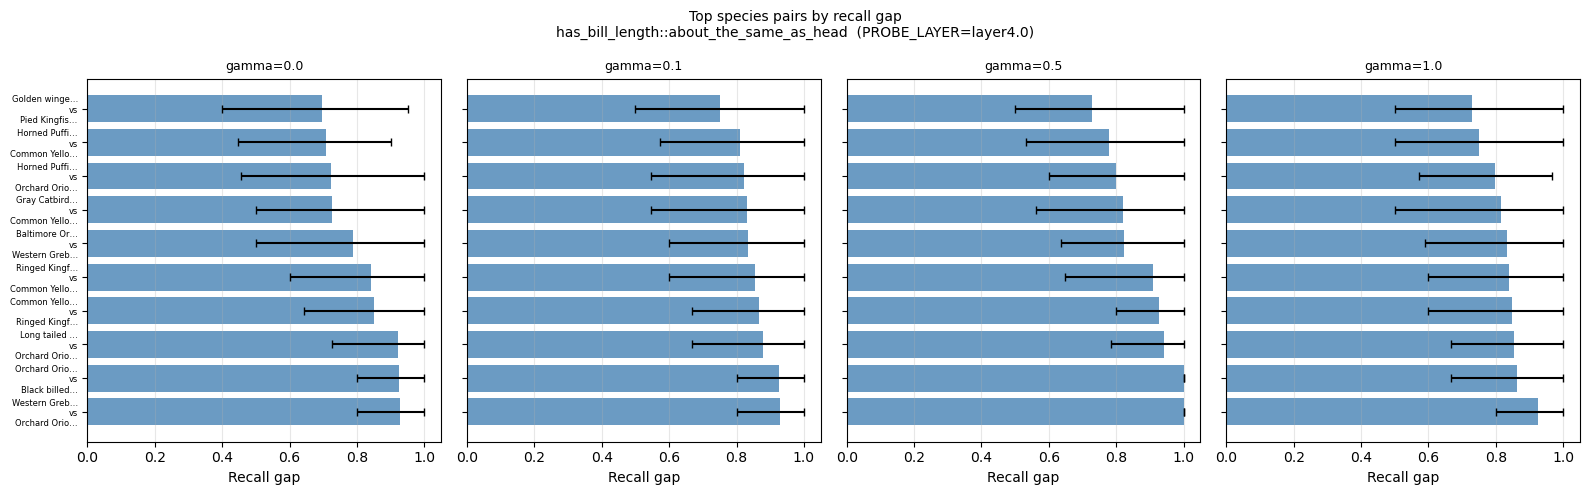

In [35]:
# ── Cell 8-5: Top species pairs for most-entangled attribute at gamma=0 ──────
# Bar chart of per-pair gap_mean with 95% CI error bars, stacked by gamma.

best_attr = ATTR_LIST[0] if ATTR_LIST else None

if best_attr:
    fig, axes = plt.subplots(1, len(GAMMAS), figsize=(4 * len(GAMMAS), 5), sharey=True)
    if len(GAMMAS) == 1:
        axes = [axes]

    for ax, g in zip(axes, GAMMAS):
        _, pairs, _ = mcbm_results[g]
        if pairs.empty:
            ax.set_title(f"gamma={g}\n(no data)")
            continue
        sub = pairs[pairs["attr"] == best_attr].head(10)
        if sub.empty:
            ax.set_title(f"gamma={g}\n(no pairs)")
            continue
        labels = [f"{r.species_A[:12]}…\nvs\n{r.species_B[:12]}…"
                  for r in sub.itertuples()]
        errs   = [
            sub["gap_mean"].values - sub["gap_ci_lo"].values,
            sub["gap_ci_hi"].values - sub["gap_mean"].values,
        ]
        ax.barh(range(len(sub)), sub["gap_mean"].values,
                xerr=errs, capsize=3, color="steelblue", alpha=0.8)
        ax.set_yticks(range(len(sub)))
        ax.set_yticklabels(labels, fontsize=6)
        ax.set_xlabel("Recall gap")
        ax.set_title(f"gamma={g}", fontsize=9)
        ax.grid(True, alpha=0.3, axis="x")
        ax.invert_yaxis()

    fig.suptitle(f"Top species pairs by recall gap\n{best_attr}  (PROBE_LAYER={PROBE_LAYER})",
                 fontsize=10)
    plt.tight_layout()
    plt.savefig(f"mcbm_top_pairs_{best_attr[:30].replace('::', '_')}.png", dpi=150)
    plt.show()

KeyError: 'recall_hi_lo'

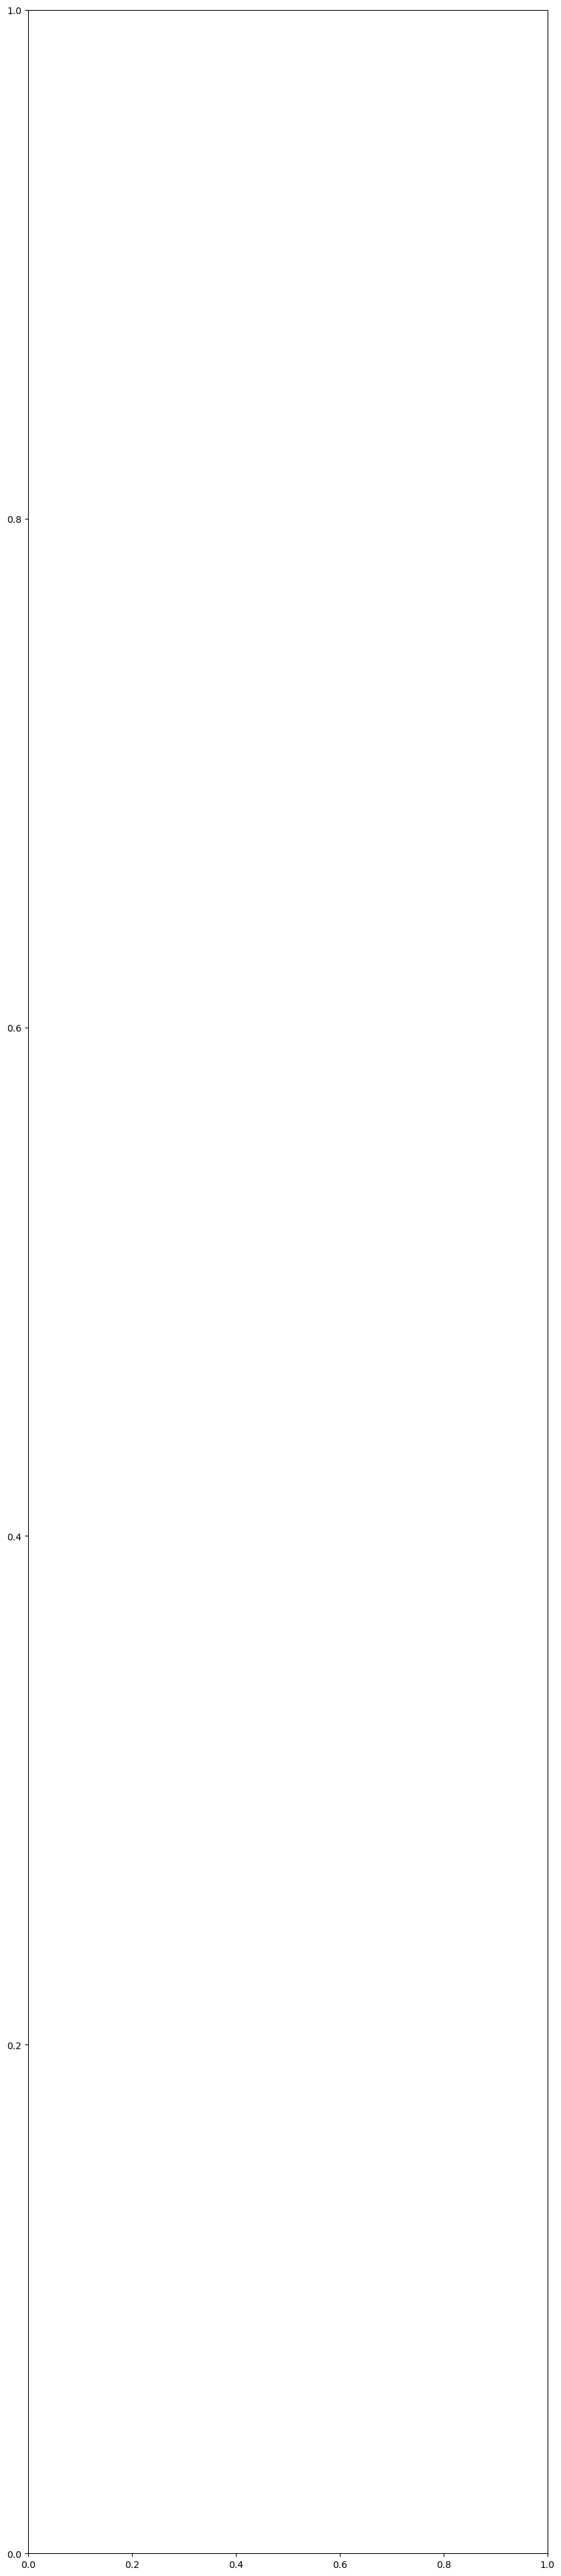

In [36]:
# ── Cell 8-6: Per-species recall scatter (CI) — gamma=0 vs gamma=max ─────────
# Each dot = one species. Error bars = bootstrap 95% CI.
# Useful for spotting which specific species are driving the recall gap.

if best_attr:
    _, _, sp_lo = mcbm_results[GAMMAS[0]]
    _, _, sp_hi = mcbm_results[GAMMAS[-1]]

    def _attr_species(sp_df, attr):
        return (sp_df[sp_df["attr"] == attr]
                    .dropna(subset=["recall"])
                    .sort_values("recall", ascending=False)
                    .reset_index(drop=True))

    slo = _attr_species(sp_lo, best_attr)
    shi = _attr_species(sp_hi, best_attr)

    if len(slo) and len(shi):
        merged_sp = slo.merge(shi, on="species_name", suffixes=("_lo", "_hi"))
        merged_sp = merged_sp.sort_values("recall_lo", ascending=False).reset_index(drop=True)

        fig, ax = plt.subplots(figsize=(10, max(4, len(merged_sp) * 0.28)))
        y = np.arange(len(merged_sp))

        # Plot CI bars for gamma=0
        if "recall_ci_lo_lo" in merged_sp.columns:
            ax.barh(y + 0.15,
                    merged_sp["recall_hi_lo"] - merged_sp["recall_ci_lo_lo"],
                    left=merged_sp["recall_ci_lo_lo"],
                    height=0.2, alpha=0.3, color="steelblue")
        ax.scatter(merged_sp["recall_lo"], y + 0.15,
                   color="steelblue", s=30, zorder=3, label=f"gamma={GAMMAS[0]}")

        # Plot CI bars for gamma=max
        if "recall_ci_lo_hi" in merged_sp.columns:
            ax.barh(y - 0.15,
                    merged_sp["recall_hi_hi"] - merged_sp["recall_ci_lo_hi"],
                    left=merged_sp["recall_ci_lo_hi"],
                    height=0.2, alpha=0.3, color="darkorange")
        ax.scatter(merged_sp["recall_hi"], y - 0.15,
                   color="darkorange", s=30, zorder=3, label=f"gamma={GAMMAS[-1]}")

        ax.set_yticks(y)
        ax.set_yticklabels(merged_sp["species_name"], fontsize=7)
        ax.set_xlabel("Recall")
        ax.set_title(f"Per-species recall: gamma={GAMMAS[0]} vs gamma={GAMMAS[-1]}\n{best_attr}")
        ax.legend()
        ax.grid(True, alpha=0.3, axis="x")
        ax.set_xlim(0, 1.05)
        plt.tight_layout()
        plt.savefig(f"mcbm_species_recall_ci_{best_attr[:30].replace('::', '_')}.png", dpi=150)
        plt.show()

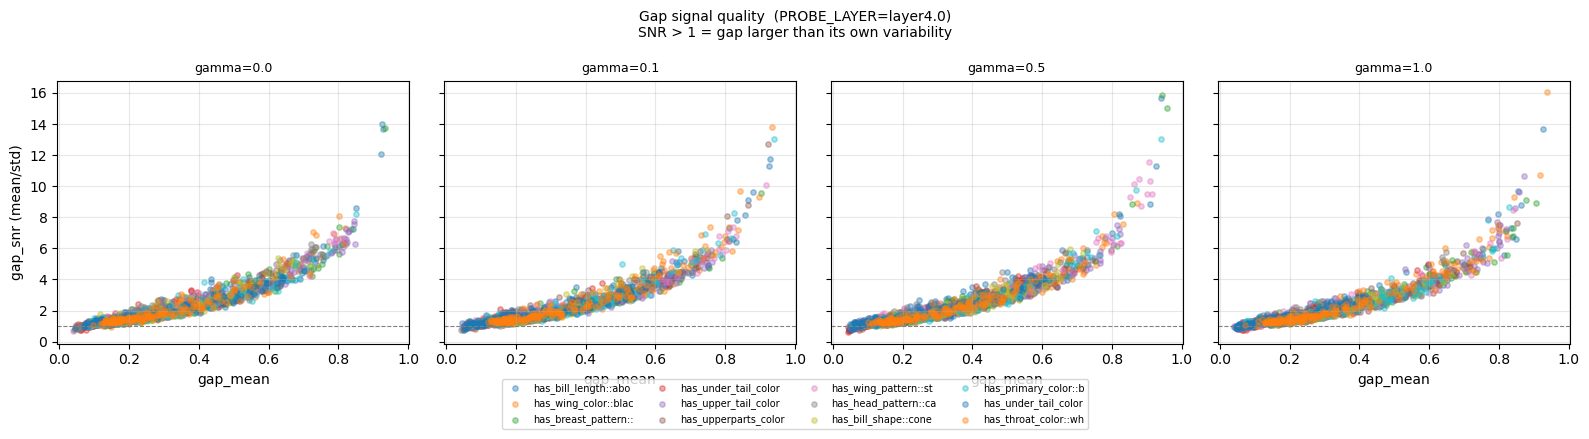

In [37]:
# ── Cell 8-7: Gap SNR vs gap mean scatter — signal quality by gamma ──────────
# Points = (attr, species_pair). SNR = gap_mean / gap_std.
# High SNR + high gap = reliable evidence of species-entanglement.

fig, axes = plt.subplots(1, len(GAMMAS), figsize=(4 * len(GAMMAS), 4), sharey=True, sharex=True)
if len(GAMMAS) == 1:
    axes = [axes]

for ax, g in zip(axes, GAMMAS):
    _, pairs, _ = mcbm_results[g]
    if pairs.empty:
        ax.set_title(f"gamma={g}\n(no data)"); continue
    pairs_e = add_gap_interpretability_cols(pairs)
    for attr in ATTR_LIST:
        sub = pairs_e[pairs_e["attr"] == attr]
        if sub.empty: continue
        ax.scatter(sub["gap_mean"], sub["gap_snr"],
                   alpha=0.4, s=15, label=attr[:20])
    ax.axhline(1, color="gray", linestyle="--", linewidth=0.8)
    ax.set_xlabel("gap_mean")
    ax.set_title(f"gamma={g}", fontsize=9)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("gap_snr (mean/std)")
fig.suptitle(f"Gap signal quality  (PROBE_LAYER={PROBE_LAYER})\n"
             "SNR > 1 = gap larger than its own variability", fontsize=10)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=7,
           bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
plt.savefig("mcbm_gap_snr_scatter.png", dpi=150)
plt.show()

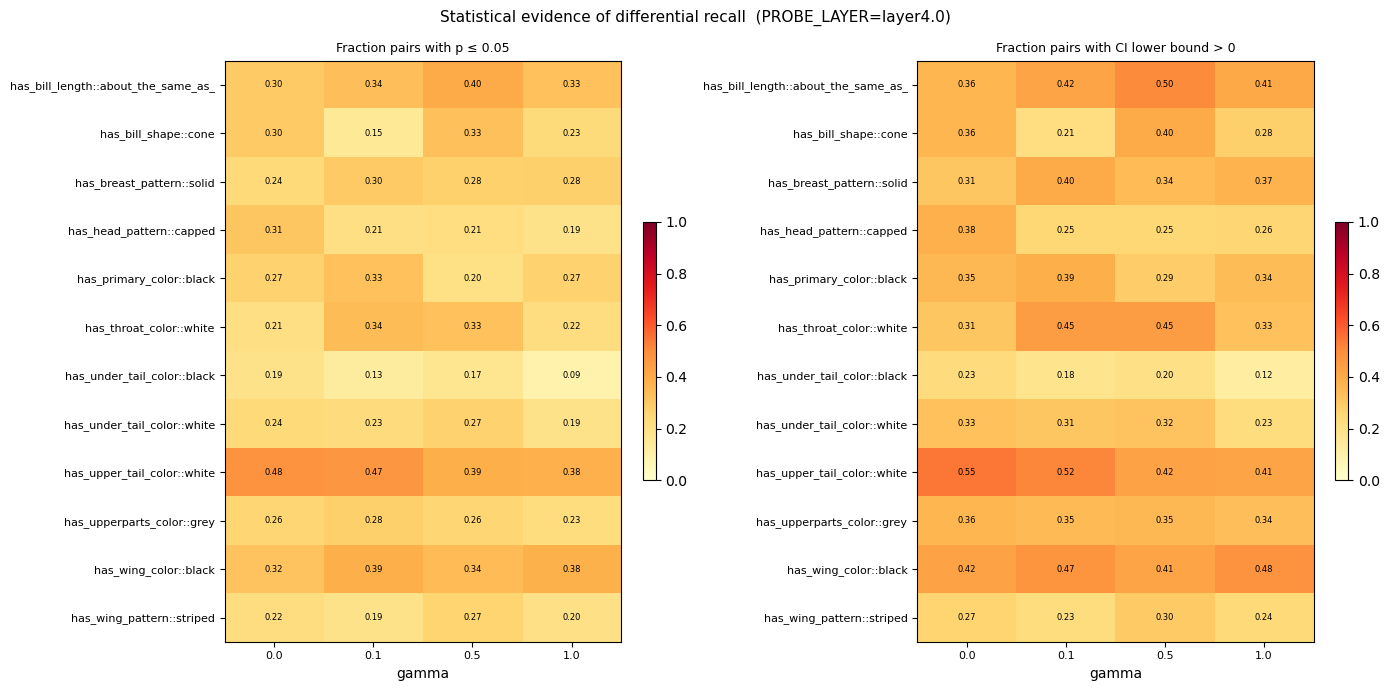

In [38]:
# ── Cell 8-8: Fraction of significant pairs heatmap — attr × gamma ───────────
# frac_p_small = fraction of species pairs with bootstrap p ≤ 0.05.
# High value = strong statistical evidence of differential recall.

heat_rows = []
for g in GAMMAS:
    _, pairs, _ = mcbm_results[g]
    if pairs.empty: continue
    pairs["_p_small"] = pairs["gap_p"] <= 0.05
    for attr in ATTR_LIST:
        sub = pairs[pairs["attr"] == attr]
        heat_rows.append({
            "gamma": g,
            "attr":  attr[:35],
            "frac_p_small":   float(sub["_p_small"].mean()) if len(sub) else np.nan,
            "frac_ci_above0": float((sub["gap_ci_lo"] > 0).mean()) if len(sub) else np.nan,
        })

df_heat = pd.DataFrame(heat_rows)

if not df_heat.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, max(3, len(ATTR_LIST) * 0.5 + 1)))

    for ax, col, title in zip(
        axes,
        ["frac_p_small", "frac_ci_above0"],
        ["Fraction pairs with p ≤ 0.05", "Fraction pairs with CI lower bound > 0"],
    ):
        pivot = df_heat.pivot(index="attr", columns="gamma", values=col)
        im = ax.imshow(pivot.values, aspect="auto", cmap="YlOrRd", vmin=0, vmax=1)
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels([str(g) for g in pivot.columns], fontsize=8)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index, fontsize=8)
        ax.set_xlabel("gamma"); ax.set_title(title, fontsize=9)
        plt.colorbar(im, ax=ax, fraction=0.03)
        for i in range(pivot.shape[0]):
            for j in range(pivot.shape[1]):
                v = pivot.values[i, j]
                if np.isfinite(v):
                    ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6,
                            color="white" if v > 0.6 else "black")

    fig.suptitle(f"Statistical evidence of differential recall  (PROBE_LAYER={PROBE_LAYER})",
                 fontsize=11)
    plt.tight_layout()
    plt.savefig("mcbm_significance_heatmap.png", dpi=150)
    plt.show()